In [4]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

In [5]:
# ============================================================
# PROBLEM UNDERSTANDING
# ============================================================

print("Project Title : Student Performance Prediction System")
print("Problem Type  : Multi-Class Classification")
print("Target Column : Class")

print("""
Objective:
Predict whether a student belongs to
Low (L), Medium (M), or High (H)
performance category based on
academic and behavioural factors.
""")

Project Title : Student Performance Prediction System
Problem Type  : Multi-Class Classification
Target Column : Class

Objective:
Predict whether a student belongs to
Low (L), Medium (M), or High (H)
performance category based on
academic and behavioural factors.



In [6]:
# ============================================================
# DATA UNDERSTANDING
# ============================================================

df = pd.read_csv(r"C:\CodingFiles\SummerTraining\Student Performance\Dataset\student_performance.csv")

print("Dataset Shape:")
print(df.shape)

print("\nFirst Five Records:")
display(df.head())

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Info:")
df.info()

print("\nMissing Values:")
display(df.isnull().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())

print("\nStatistical Summary:")
display(df.describe())

print("\nUnique Values:")
display(df.nunique())

Dataset Shape:
(480, 17)

First Five Records:


,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M



Column Names:
['gender', 'NationalITy', 'PlaceofBirth', 'StageID', 'GradeID', 'SectionID', 'Topic', 'Semester', 'Relation', 'raisedhands', 'VisITedResources', 'AnnouncementsView', 'Discussion', 'ParentAnsweringSurvey', 'ParentschoolSatisfaction', 'StudentAbsenceDays', 'Class']

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   gender                    480 non-null    str  
 1   NationalITy               480 non-null    str  
 2   PlaceofBirth              480 non-null    str  
 3   StageID                   480 non-null    str  
 4   GradeID                   480 non-null    str  
 5   SectionID                 480 non-null    str  
 6   Topic                     480 non-null    str  
 7   Semester                  480 non-null    str  
 8   Relation                  480 non-null    str  
 9   raisedhands             

gender                      0
NationalITy                 0
PlaceofBirth                0
StageID                     0
GradeID                     0
SectionID                   0
Topic                       0
Semester                    0
Relation                    0
raisedhands                 0
VisITedResources            0
AnnouncementsView           0
Discussion                  0
ParentAnsweringSurvey       0
ParentschoolSatisfaction    0
StudentAbsenceDays          0
Class                       0
dtype: int64


Duplicate Records:
2

Statistical Summary:


,raisedhands,VisITedResources,AnnouncementsView,Discussion
count,480.000000,480.000000,480.000000,480.000000
mean,46.775000,54.797917,37.918750,43.283333
std,30.779223,33.080007,26.611244,27.637735
min,0.000000,0.000000,0.000000,1.000000
25%,15.750000,20.000000,14.000000,20.000000
50%,50.000000,65.000000,33.000000,39.000000
75%,75.000000,84.000000,58.000000,70.000000
max,100.000000,99.000000,98.000000,99.000000



Unique Values:


gender                       2
NationalITy                 14
PlaceofBirth                14
StageID                      3
GradeID                     10
SectionID                    3
Topic                       12
Semester                     2
Relation                     2
raisedhands                 82
VisITedResources            89
AnnouncementsView           88
Discussion                  90
ParentAnsweringSurvey        2
ParentschoolSatisfaction     2
StudentAbsenceDays           2
Class                        3
dtype: int64

Shape After Duplicate Removal:
(478, 17)

Missing Values:


gender                      0
NationalITy                 0
PlaceofBirth                0
StageID                     0
GradeID                     0
SectionID                   0
Topic                       0
Semester                    0
Relation                    0
raisedhands                 0
VisITedResources            0
AnnouncementsView           0
Discussion                  0
ParentAnsweringSurvey       0
ParentschoolSatisfaction    0
StudentAbsenceDays          0
Class                       0
dtype: int64

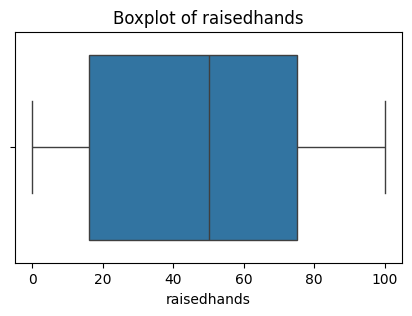

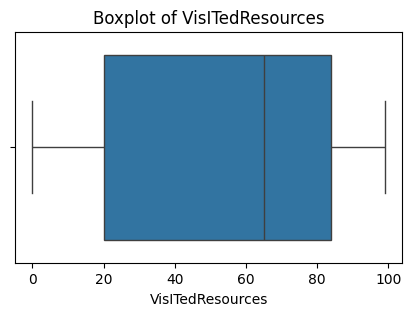

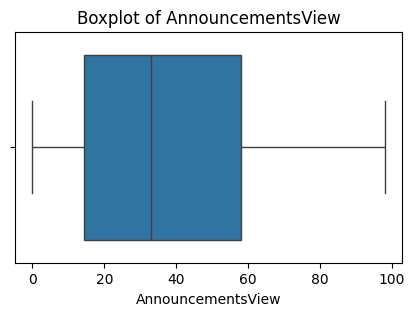

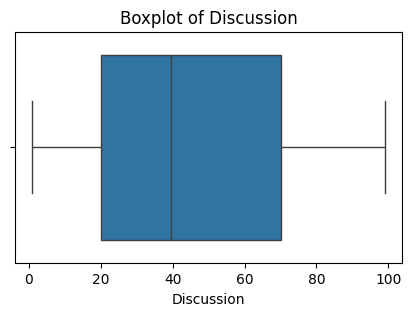

In [7]:
# ============================================================
# DATA PREPROCESSING
# ============================================================

# Remove duplicates

df = df.drop_duplicates()

print("Shape After Duplicate Removal:")
print(df.shape)

# Check Missing Values

print("\nMissing Values:")
display(df.isnull().sum())

# Numerical Columns

numerical_cols = [
    'raisedhands',
    'VisITedResources',
    'AnnouncementsView',
    'Discussion'
]

# Boxplots for Outlier Detection

for col in numerical_cols:

    plt.figure(figsize=(5,3))

    sns.boxplot(x=df[col])

    plt.title(f'Boxplot of {col}')

    plt.show()

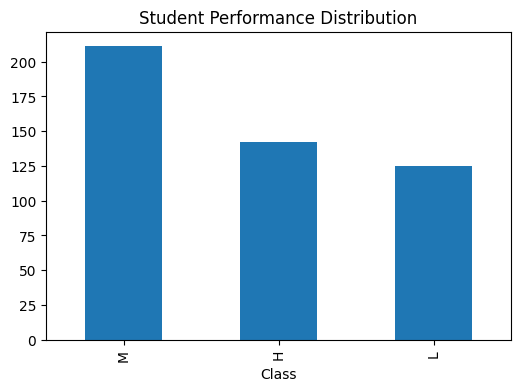

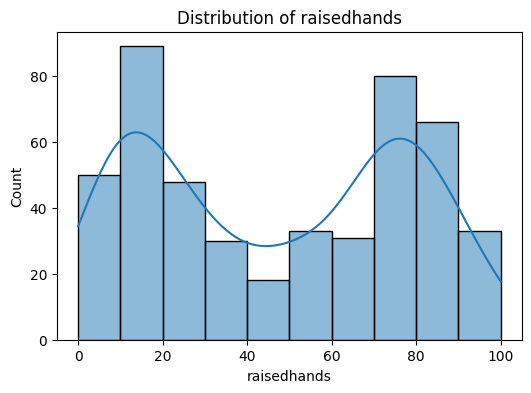

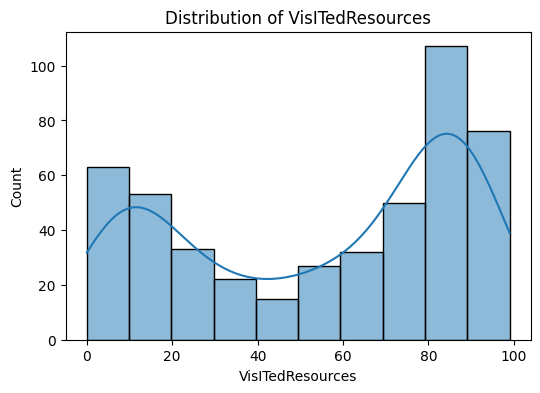

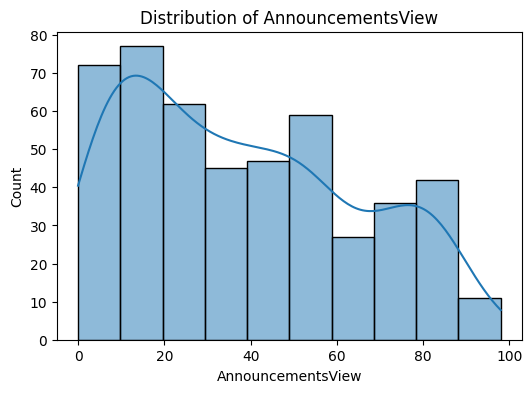

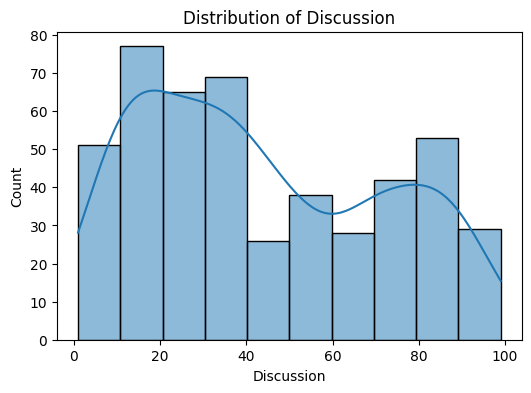

In [8]:
# ============================================================
# UNIVARIATE ANALYSIS
# ============================================================

df['Class'].value_counts().plot(
    kind='bar',
    figsize=(6,4)
)

plt.title("Student Performance Distribution")
plt.show()

for col in numerical_cols:

    plt.figure(figsize=(6,4))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(f'Distribution of {col}')

    plt.show()

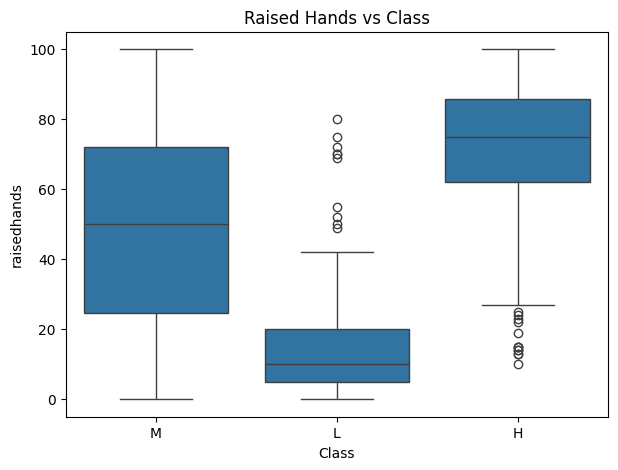

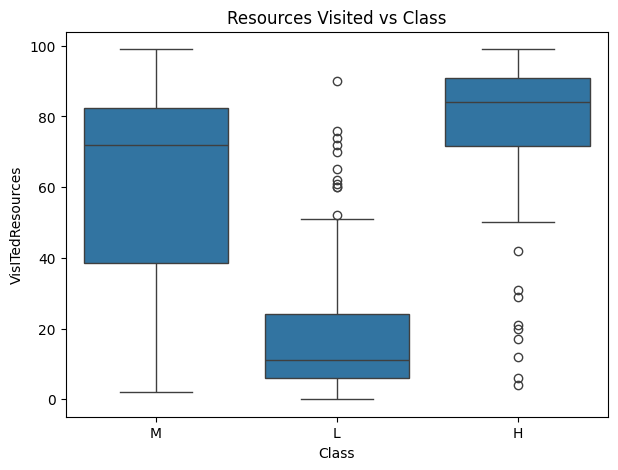

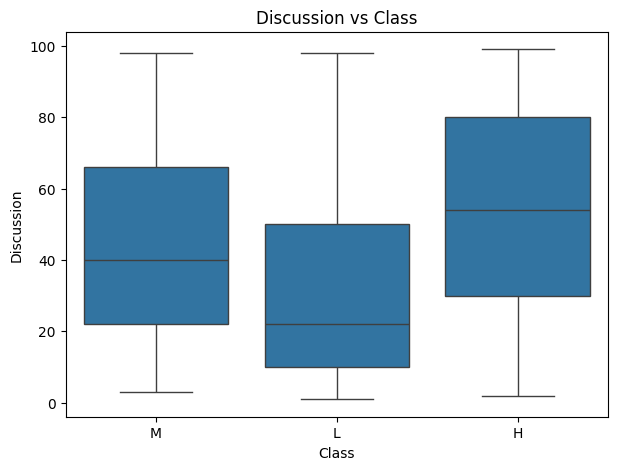

In [9]:
# ============================================================
# BIVARIATE ANALYSIS
# ============================================================

plt.figure(figsize=(7,5))

sns.boxplot(
    x='Class',
    y='raisedhands',
    data=df
)

plt.title("Raised Hands vs Class")
plt.show()

plt.figure(figsize=(7,5))

sns.boxplot(
    x='Class',
    y='VisITedResources',
    data=df
)

plt.title("Resources Visited vs Class")
plt.show()

plt.figure(figsize=(7,5))

sns.boxplot(
    x='Class',
    y='Discussion',
    data=df
)

plt.title("Discussion vs Class")
plt.show()

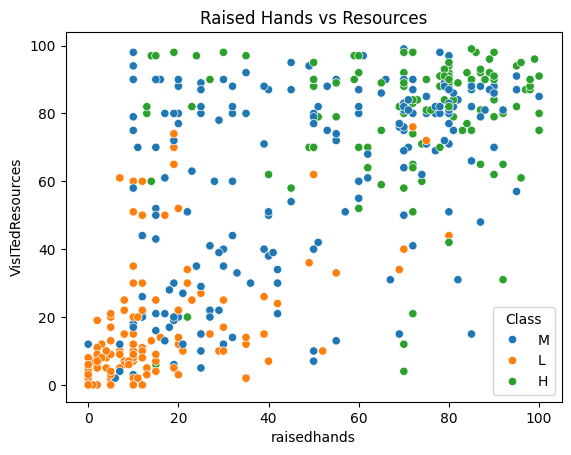

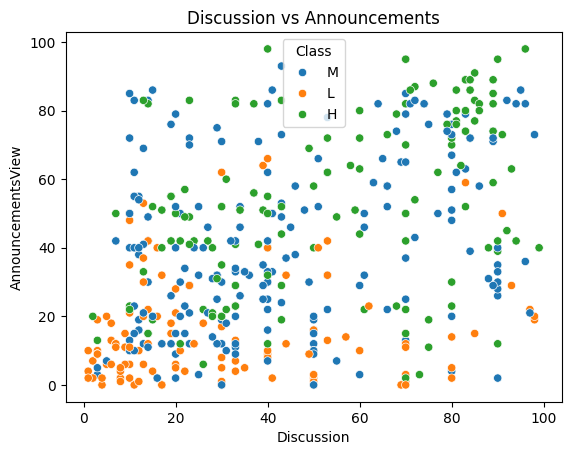

In [10]:
# ============================================================
# SCATTER PLOTS
# ============================================================

sns.scatterplot(
    x='raisedhands',
    y='VisITedResources',
    hue='Class',
    data=df
)

plt.title("Raised Hands vs Resources")
plt.show()

sns.scatterplot(
    x='Discussion',
    y='AnnouncementsView',
    hue='Class',
    data=df
)

plt.title("Discussion vs Announcements")
plt.show()

In [11]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================

data = df.copy()

label_encoders = {}

categorical_cols = data.select_dtypes(
    include='object'
).columns

for col in categorical_cols:

    le = LabelEncoder()

    data[col] = le.fit_transform(
        data[col]
    )

    label_encoders[col] = le

print("Encoded Dataset:")
display(data.head())

Encoded Dataset:


,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,1,4,4,2,1,0,7,0,0,15,16,2,20,1,1,1,2
1,1,4,4,2,1,0,7,0,0,20,20,3,25,1,1,1,2
2,1,4,4,2,1,0,7,0,0,10,7,0,30,0,0,0,1
3,1,4,4,2,1,0,7,0,0,30,25,5,35,0,0,0,1
4,1,4,4,2,1,0,7,0,0,40,50,12,50,0,0,0,2


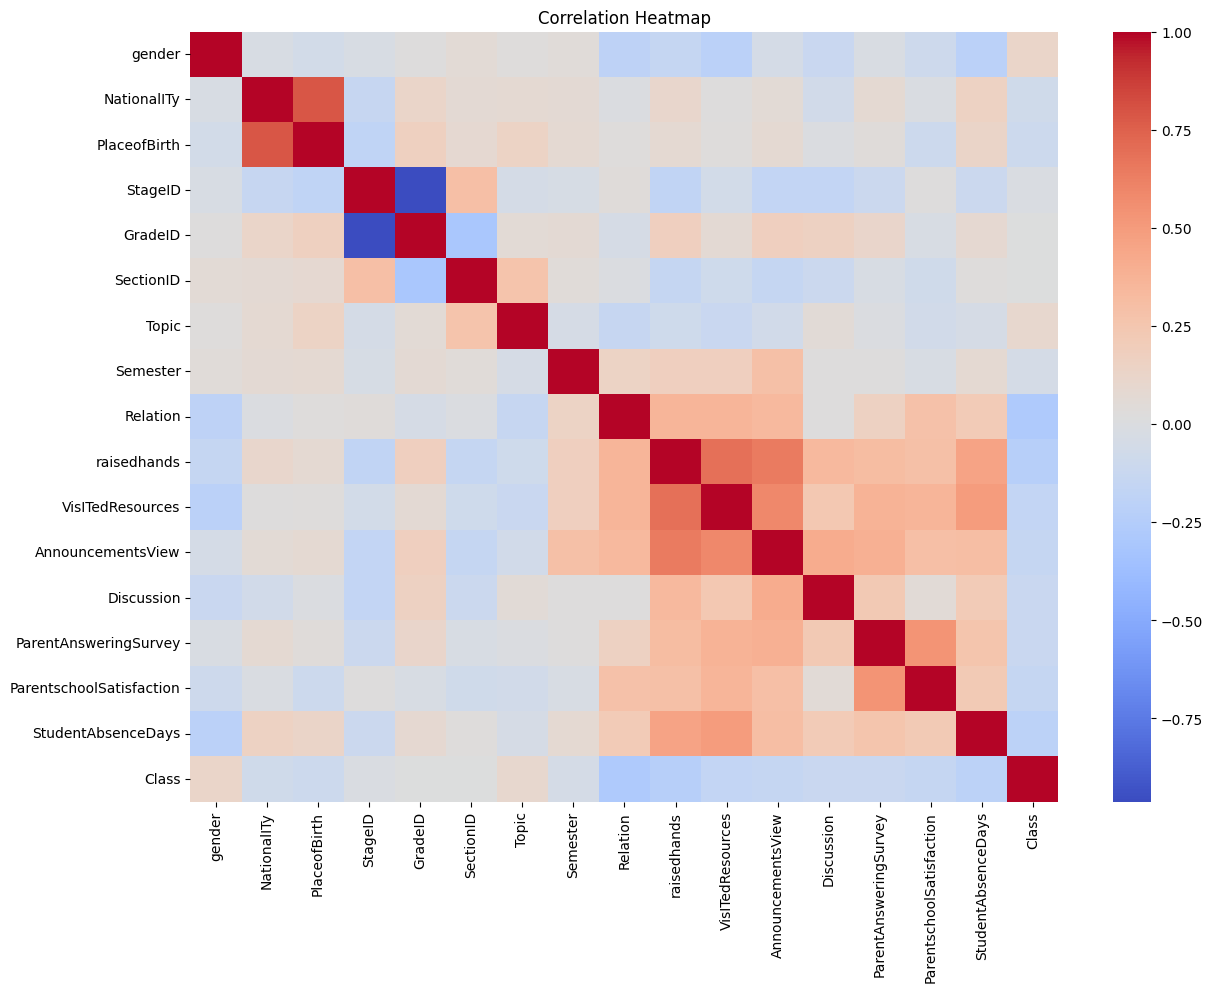

In [12]:
# ============================================================
# CORRELATION ANALYSIS
# ============================================================

plt.figure(figsize=(14,10))

sns.heatmap(
    data.corr(),
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Heatmap")
plt.show()

In [13]:
# ============================================================
# FEATURE SELECTION
# ============================================================

corr_target = data.corr()['Class']

corr_target = corr_target.sort_values(
    ascending=False
)

print(corr_target)

Class                       1.000000
gender                      0.124371
Topic                       0.103382
SectionID                   0.017070
GradeID                     0.012680
StageID                    -0.010952
Semester                   -0.043366
NationalITy                -0.078226
PlaceofBirth               -0.099419
Discussion                 -0.123091
ParentAnsweringSurvey      -0.124403
AnnouncementsView          -0.144854
ParentschoolSatisfaction   -0.147653
VisITedResources           -0.163231
StudentAbsenceDays         -0.200606
raisedhands                -0.232069
Relation                   -0.273119
Name: Class, dtype: float64


In [14]:
# ============================================================
# FEATURES AND TARGET
# ============================================================

X = data.drop('Class', axis=1)

y = data['Class']

print(X.shape)
print(y.shape)

(478, 16)
(478,)


In [15]:
# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(382, 16)
(96, 16)


In [16]:
# ============================================================
# MODEL BUILDING
# ============================================================

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=2000),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(random_state=42),

    "KNN":
        KNeighborsClassifier(),

    "SVM":
        SVC()
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        pred
    )

    precision = precision_score(
        y_test,
        pred,
        average='weighted'
    )

    recall = recall_score(
        y_test,
        pred,
        average='weighted'
    )

    f1 = f1_score(
        y_test,
        pred,
        average='weighted'
    )

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

    print("\n")
    print("="*50)
    print(name)
    print("="*50)

    print(classification_report(
        y_test,
        pred
    ))



Logistic Regression
              precision    recall  f1-score   support

           0       0.67      0.62      0.64        29
           1       0.85      0.88      0.86        25
           2       0.67      0.69      0.68        42

    accuracy                           0.72        96
   macro avg       0.73      0.73      0.73        96
weighted avg       0.72      0.72      0.72        96



Decision Tree
              precision    recall  f1-score   support

           0       0.70      0.72      0.71        29
           1       0.81      0.84      0.82        25
           2       0.75      0.71      0.73        42

    accuracy                           0.75        96
   macro avg       0.75      0.76      0.76        96
weighted avg       0.75      0.75      0.75        96



Random Forest
              precision    recall  f1-score   support

           0       0.81      0.72      0.76        29
           1       0.82      0.92      0.87        25
           2       0.

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.791667,0.791237,0.791667,0.790037
1,Decision Tree,0.750000,0.749920,0.750000,0.749625
0,Logistic Regression,0.718750,0.716800,0.718750,0.717399
4,SVM,0.635417,0.632674,0.635417,0.632679
3,KNN,0.604167,0.603605,0.604167,0.603561


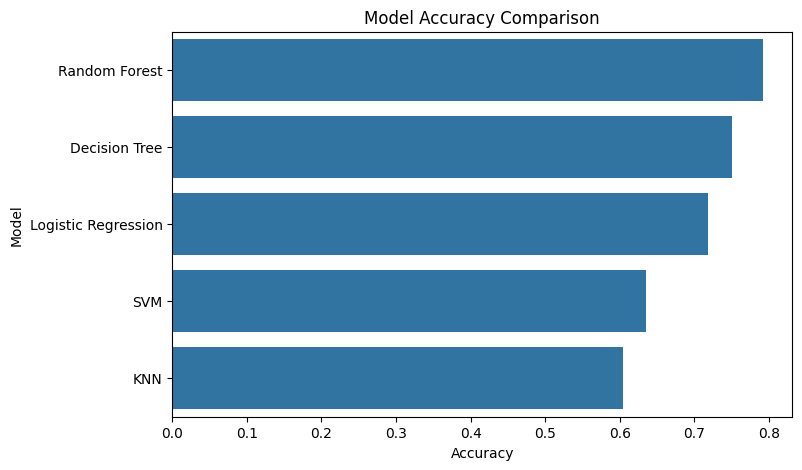

In [17]:
# ============================================================
# MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ]
)

results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

display(results_df)

plt.figure(figsize=(8,5))

sns.barplot(
    x='Accuracy',
    y='Model',
    data=results_df
)

plt.title("Model Accuracy Comparison")

plt.show()

In [18]:
# ============================================================
# BEST MODEL
# ============================================================

best_model_name = results_df.iloc[0]['Model']

best_model = models[best_model_name]

predictions = best_model.predict(X_test)

print("Best Model:")
print(best_model_name)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        predictions
    )
)

Best Model:
Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.72      0.76        29
           1       0.82      0.92      0.87        25
           2       0.76      0.76      0.76        42

    accuracy                           0.79        96
   macro avg       0.80      0.80      0.80        96
weighted avg       0.79      0.79      0.79        96



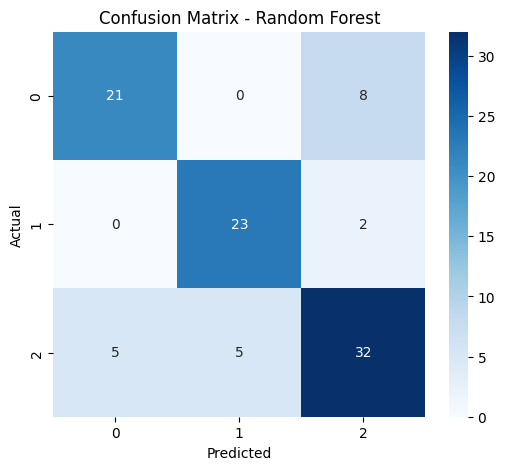

In [19]:
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(
        y_test,
        predictions
    ),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    f'Confusion Matrix - {best_model_name}'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

,Feature,Importance
10,VisITedResources,0.183617
9,raisedhands,0.159983
15,StudentAbsenceDays,0.121833
11,AnnouncementsView,0.117814
12,Discussion,0.096979
6,Topic,0.045650
13,ParentAnsweringSurvey,0.041955
1,NationalITy,0.041377
8,Relation,0.038115
2,PlaceofBirth,0.036227


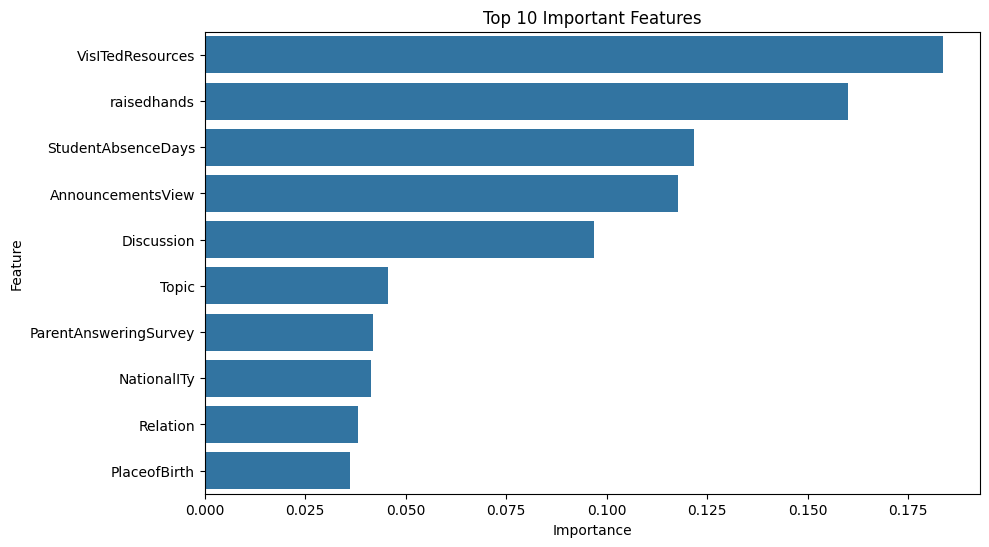

In [20]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance':
        rf.feature_importances_

})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

display(
    importance.head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title(
    "Top 10 Important Features"
)

plt.show()

In [22]:
import joblib

joblib.dump({
    "model": best_model,
    "encoders": label_encoders
}, "student_performance_model.pkl")

print("Model and Encoders Saved Successfully")

Model and Encoders Saved Successfully


In [25]:
import joblib

saved_data = joblib.load("../Model/student_performance_model.pkl")

print(saved_data)

{'model': RandomForestClassifier(random_state=42), 'encoders': {'gender': LabelEncoder(), 'NationalITy': LabelEncoder(), 'PlaceofBirth': LabelEncoder(), 'StageID': LabelEncoder(), 'GradeID': LabelEncoder(), 'SectionID': LabelEncoder(), 'Topic': LabelEncoder(), 'Semester': LabelEncoder(), 'Relation': LabelEncoder(), 'ParentAnsweringSurvey': LabelEncoder(), 'ParentschoolSatisfaction': LabelEncoder(), 'StudentAbsenceDays': LabelEncoder(), 'Class': LabelEncoder()}}


In [26]:
print(df.columns.tolist())

['gender', 'NationalITy', 'PlaceofBirth', 'StageID', 'GradeID', 'SectionID', 'Topic', 'Semester', 'Relation', 'raisedhands', 'VisITedResources', 'AnnouncementsView', 'Discussion', 'ParentAnsweringSurvey', 'ParentschoolSatisfaction', 'StudentAbsenceDays', 'Class']


In [27]:
import joblib

saved_data = joblib.load("../Model/student_performance_model.pkl")

encoders = saved_data["encoders"]

for col, encoder in encoders.items():
    print(f"\n{col}")
    print(list(encoder.classes_))


gender
['F', 'M']

NationalITy
['Egypt', 'Iran', 'Iraq', 'Jordan', 'KW', 'Lybia', 'Morocco', 'Palestine', 'SaudiArabia', 'Syria', 'Tunis', 'USA', 'lebanon', 'venzuela']

PlaceofBirth
['Egypt', 'Iran', 'Iraq', 'Jordan', 'KuwaIT', 'Lybia', 'Morocco', 'Palestine', 'SaudiArabia', 'Syria', 'Tunis', 'USA', 'lebanon', 'venzuela']

StageID
['HighSchool', 'MiddleSchool', 'lowerlevel']

GradeID
['G-02', 'G-04', 'G-05', 'G-06', 'G-07', 'G-08', 'G-09', 'G-10', 'G-11', 'G-12']

SectionID
['A', 'B', 'C']

Topic
['Arabic', 'Biology', 'Chemistry', 'English', 'French', 'Geology', 'History', 'IT', 'Math', 'Quran', 'Science', 'Spanish']

Semester
['F', 'S']

Relation
['Father', 'Mum']

ParentAnsweringSurvey
['No', 'Yes']

ParentschoolSatisfaction
['Bad', 'Good']

StudentAbsenceDays
['Above-7', 'Under-7']

Class
['H', 'L', 'M']


In [29]:
saved_data = joblib.load(r"C:\CodingFiles\SummerTraining\Student Performance\Model\student_performance_model.pkl")

print(saved_data.keys())

dict_keys(['model', 'encoders'])
